In [2]:
import torch
import numpy as np
from factor_analyzer.rotator import Rotator

# 1) Load parameters
model_data = torch.load('./output/mirt_model_k7.pt', map_location=torch.device('cpu'))
theta = model_data['theta']          # shape: (n_people, k)
a = model_data['a']                  # shape: (n_items,  k)
b = model_data['b']

print("--- Initial Loaded Data ---")
print(f"Original theta shape: {theta.shape}")
print(f"Original 'a' matrix shape: {a.shape}\n")

a_numpy = a.detach().cpu().numpy()
theta_numpy = theta.detach().cpu().numpy()

# 2) Rotate 'a'
rotator = Rotator(method='varimax')  # orthogonal
a_rotated_numpy = rotator.fit_transform(a_numpy)
print("--- After Rotation of 'a' ---")
print(f"Rotated 'a' matrix shape: {a_rotated_numpy.shape}\n")

# 3) Transform theta using the SAME rotation matrix from Rotator
T = rotator.rotation_                # <- correct attribute on Rotator
theta_transformed_numpy = theta_numpy @ T  # for orthogonal varimax, use R (not inv(R))

print("--- After Transformation of 'theta' ---")
print(f"Transformed theta shape: {theta_transformed_numpy.shape}\n")

# (Optional) Sanity check: inner products preserved (up to numerical tolerance)
# err = np.max(np.abs(a_numpy @ theta_numpy.T - a_rotated_numpy @ theta_transformed_numpy.T))
# print(f"Max abs diff in item-person inner products: {err:.3e}")

# 4) Standardize transformed theta
# Z-score theta for interpretability
m = theta_transformed_numpy.mean(axis=0)           # shape (K,)
s = theta_transformed_numpy.std(axis=0)            # shape (K,)
eps = 1e-8
D = np.diag(np.maximum(s, eps))
theta_z_scores_numpy = (theta_transformed_numpy - m) / np.maximum(s, eps)

# If you intend to use theta_z for prediction, adjust a and b:
a_for_z_numpy = a_rotated_numpy @ D                # (items x K)
b_for_z_numpy = b.detach().cpu().numpy() - a_rotated_numpy @ m  # (items,)

print("--- Final Standardized Z-Scores (from transformed theta) ---")
print("These are the scores you should use for interpretation.")
print(theta_z_scores_numpy)

# Convert back to torch if needed
a_rotated = torch.from_numpy(a_rotated_numpy).float()
theta_transformed = torch.from_numpy(theta_transformed_numpy).float()
theta_z_scores = torch.from_numpy(theta_z_scores_numpy).float()


--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 7])
Original 'a' matrix shape: torch.Size([78712, 7])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 7)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 7)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[-2.79948482 -0.78202985 -1.93298756 ...  0.23071324  0.89549107
   2.23566031]
 [ 0.14613676  1.83059008 -1.83839537 ... -0.57835935  0.86668647
   1.05314883]
 [-0.21110577 -1.11797513 -1.46836547 ...  1.00485595 -0.20510633
   0.43915629]
 ...
 [-2.43912155 -2.26166166  1.05527517 ...  0.51826374 -0.07370304
   0.66003036]
 [-2.81758287 -2.32154915  0.75505565 ... -0.15213182 -0.11226068
   1.30435391]
 [-2.54270949 -0.91331091 -0.32832385 ...  1.38565465 -0.07441711
  -0.09826813]]


In [1]:
import torch
import numpy as np
from factor_analyzer.rotator import Rotator

# 1) Load parameters (same as before)
model_data = torch.load('./output/mirt_model_k3.pt', map_location=torch.device('cpu'))
theta = model_data['theta']
a = model_data['a']
b = model_data['b']

a_numpy = a.detach().cpu().numpy()
theta_numpy = theta.detach().cpu().numpy()

# 2) Rotate 'a' using an OBLIQUE method
# --- CHANGED ---
rotator = Rotator(method='promax')
# a_rotated_numpy is now the PATTERN MATRIX. This is what you interpret.
a_rotated_numpy = rotator.fit_transform(a_numpy)
print("--- After Oblique Rotation of 'a' ---")
print(f"Rotated 'a' (Pattern Matrix) shape: {a_rotated_numpy.shape}\n")

# 3) Transform theta using the OBLIQUE formula
# --- CHANGED ---
T = rotator.rotation_  # The transformation matrix
# For oblique, the scores are transformed using the inverse of the transpose of T
T_inv_transpose = np.linalg.inv(T.T)
theta_transformed_numpy = theta_numpy @ T_inv_transpose

print("--- After Oblique Transformation of 'theta' ---")
print(f"Transformed theta shape: {theta_transformed_numpy.shape}\n")

# 4) *** NEW *** Get the Factor Correlation Matrix (Phi)
# This is a key result of the oblique rotation!
phi = rotator.phi_
print("--- Factor Correlation Matrix (Phi) ---")
print("This shows the correlation between your latent abilities.")
print(phi)
print("\n")


# 5) Standardize transformed theta (same logic as before)
m = theta_transformed_numpy.mean(axis=0)
s = theta_transformed_numpy.std(axis=0)
eps = 1e-8
D = np.diag(np.maximum(s, eps))
theta_z_scores_numpy = (theta_transformed_numpy - m) / np.maximum(s, eps)

# Adjust a and b for the new standardized scores
a_for_z_numpy = a_rotated_numpy @ D
b_for_z_numpy = b.detach().cpu().numpy() - a_rotated_numpy @ m

print("--- Final Standardized Z-Scores (from oblique rotation) ---")
print("These are the scores you should use for interpretation.")
print(theta_z_scores_numpy)

--- After Oblique Rotation of 'a' ---
Rotated 'a' (Pattern Matrix) shape: (78712, 3)

--- After Oblique Transformation of 'theta' ---
Transformed theta shape: (183, 3)

--- Factor Correlation Matrix (Phi) ---
This shows the correlation between your latent abilities.
[[ 1.         -0.15618253 -0.00102048]
 [-0.15618253  1.         -0.00907005]
 [-0.00102048 -0.00907005  1.        ]]


--- Final Standardized Z-Scores (from oblique rotation) ---
These are the scores you should use for interpretation.
[[ 8.06480041e-02 -1.02348929e+00 -1.70491367e+00]
 [ 6.83835875e-01 -8.34063021e-01  1.32979899e+00]
 [ 1.47672868e+00 -1.84327367e+00 -3.01062643e-01]
 [ 1.73065911e+00 -1.49804466e+00  2.42226284e-01]
 [-2.30867110e+00 -8.53050348e-01  5.00753028e-01]
 [-1.87690289e+00 -8.16558942e-01  5.08300725e-01]
 [ 1.02933128e-01 -1.48061034e+00 -1.66029779e-01]
 [ 3.89268047e-01 -7.71987793e-01  1.87769806e-01]
 [-1.49616995e+00 -1.13269094e+00  4.25920082e-01]
 [-2.12821275e+00 -8.72126306e-01  7.2

In [3]:
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta_z_scores_numpy
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

/tmp/ipykernel_9352/2438808161.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
/tmp/ipykernel_9352/2438808161.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()


Created aggregated scenario scores DataFrame with shape: (183, 40)

Dropped 0 scenarios with zero variance: []
Kept 22 scenarios for correlation analysis.


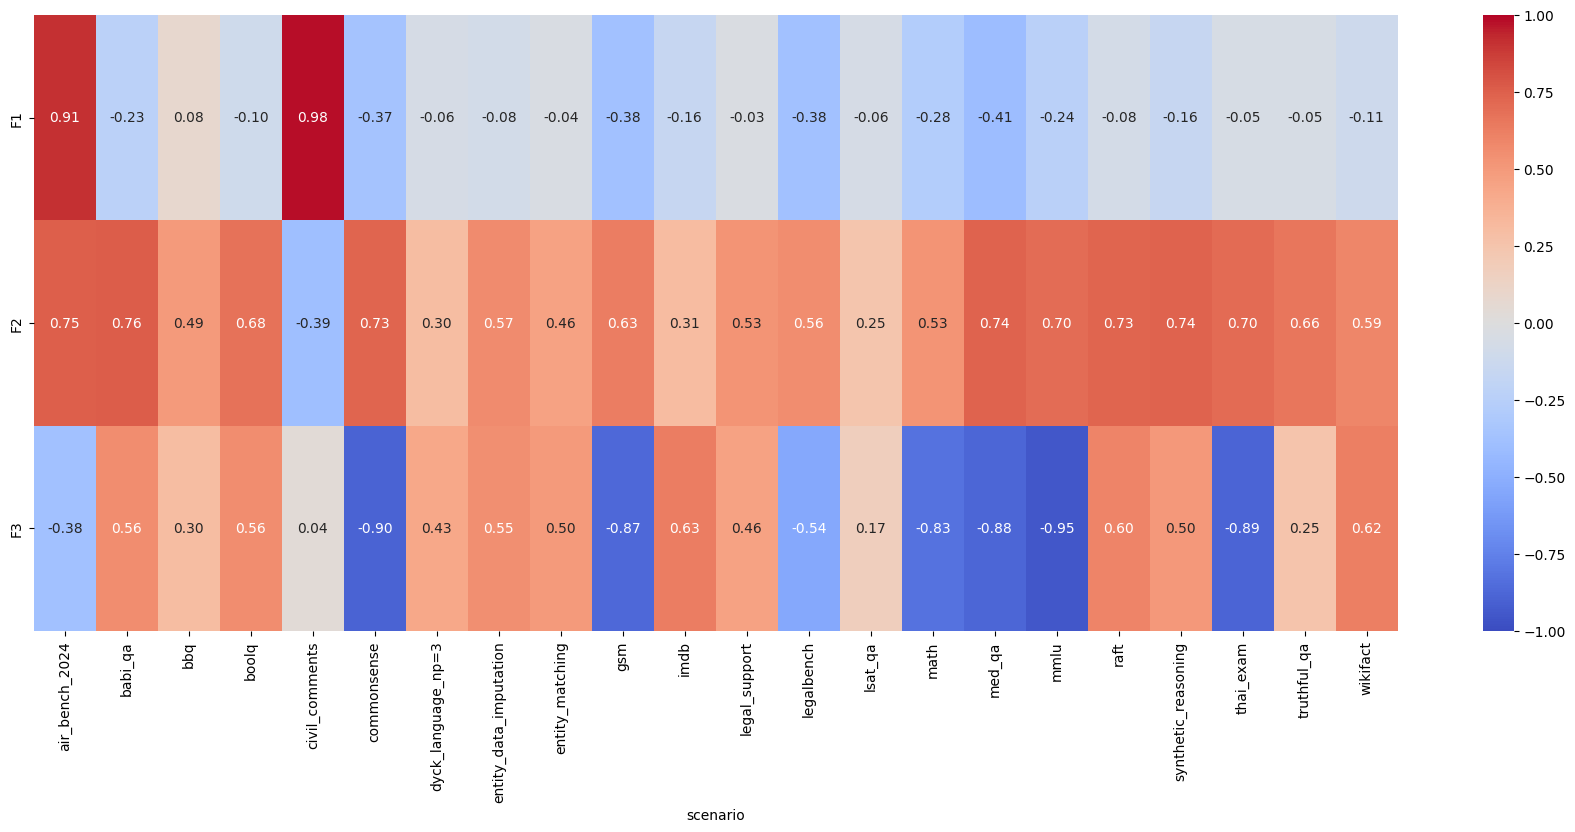

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume 'ability_df' is your (183, k) DataFrame of model abilities

# --- Step A: Aggregate resmat to get per-scenario scores ---
resmat = pd.read_pickle("../data/resmat.pkl")
scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
print(f"Created aggregated scenario scores DataFrame with shape: {scenario_scores.shape}")

# --- NEW: Step B: Identify and filter out zero-variance scenarios ---
# Calculate the standard deviation of each scenario's scores
std_devs = scenario_scores.std()

# Find the scenarios where the scores actually vary (std > 0)
scenarios_to_keep = std_devs[std_devs > 0].index
scenarios_dropped = std_devs[std_devs == 0].index

# Create a new DataFrame with only the valid scenarios
scenario_scores_filtered = scenario_scores[scenarios_to_keep]

print(f"\nDropped {len(scenarios_dropped)} scenarios with zero variance: {list(scenarios_dropped)}")
print(f"Kept {len(scenarios_to_keep)} scenarios for correlation analysis.")


# --- Step C: Combine ability scores and the FILTERED scenario scores ---
combined_df = pd.concat([ability_df, scenario_scores_filtered], axis=1)


# --- Step D: Calculate the full correlation matrix ---
full_correlations = combined_df.corr(method='spearman')


# --- Step E: Isolate and visualize the part we care about ---
# We now use the filtered list of columns
factor_scenario_corr = full_correlations.loc[ability_df.columns, scenario_scores_filtered.columns]

plt.figure(figsize=(22, 8))
sns.heatmap(factor_scenario_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.savefig("../result/factor-scenario-correlations.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_9352/3381816702.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
/tmp/ipykernel_9352/3381816702.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()


Created aggregated scenario scores DataFrame with shape: (183, 40)

Dropped 0 scenarios with zero variance: []
Kept 22 scenarios for correlation analysis.


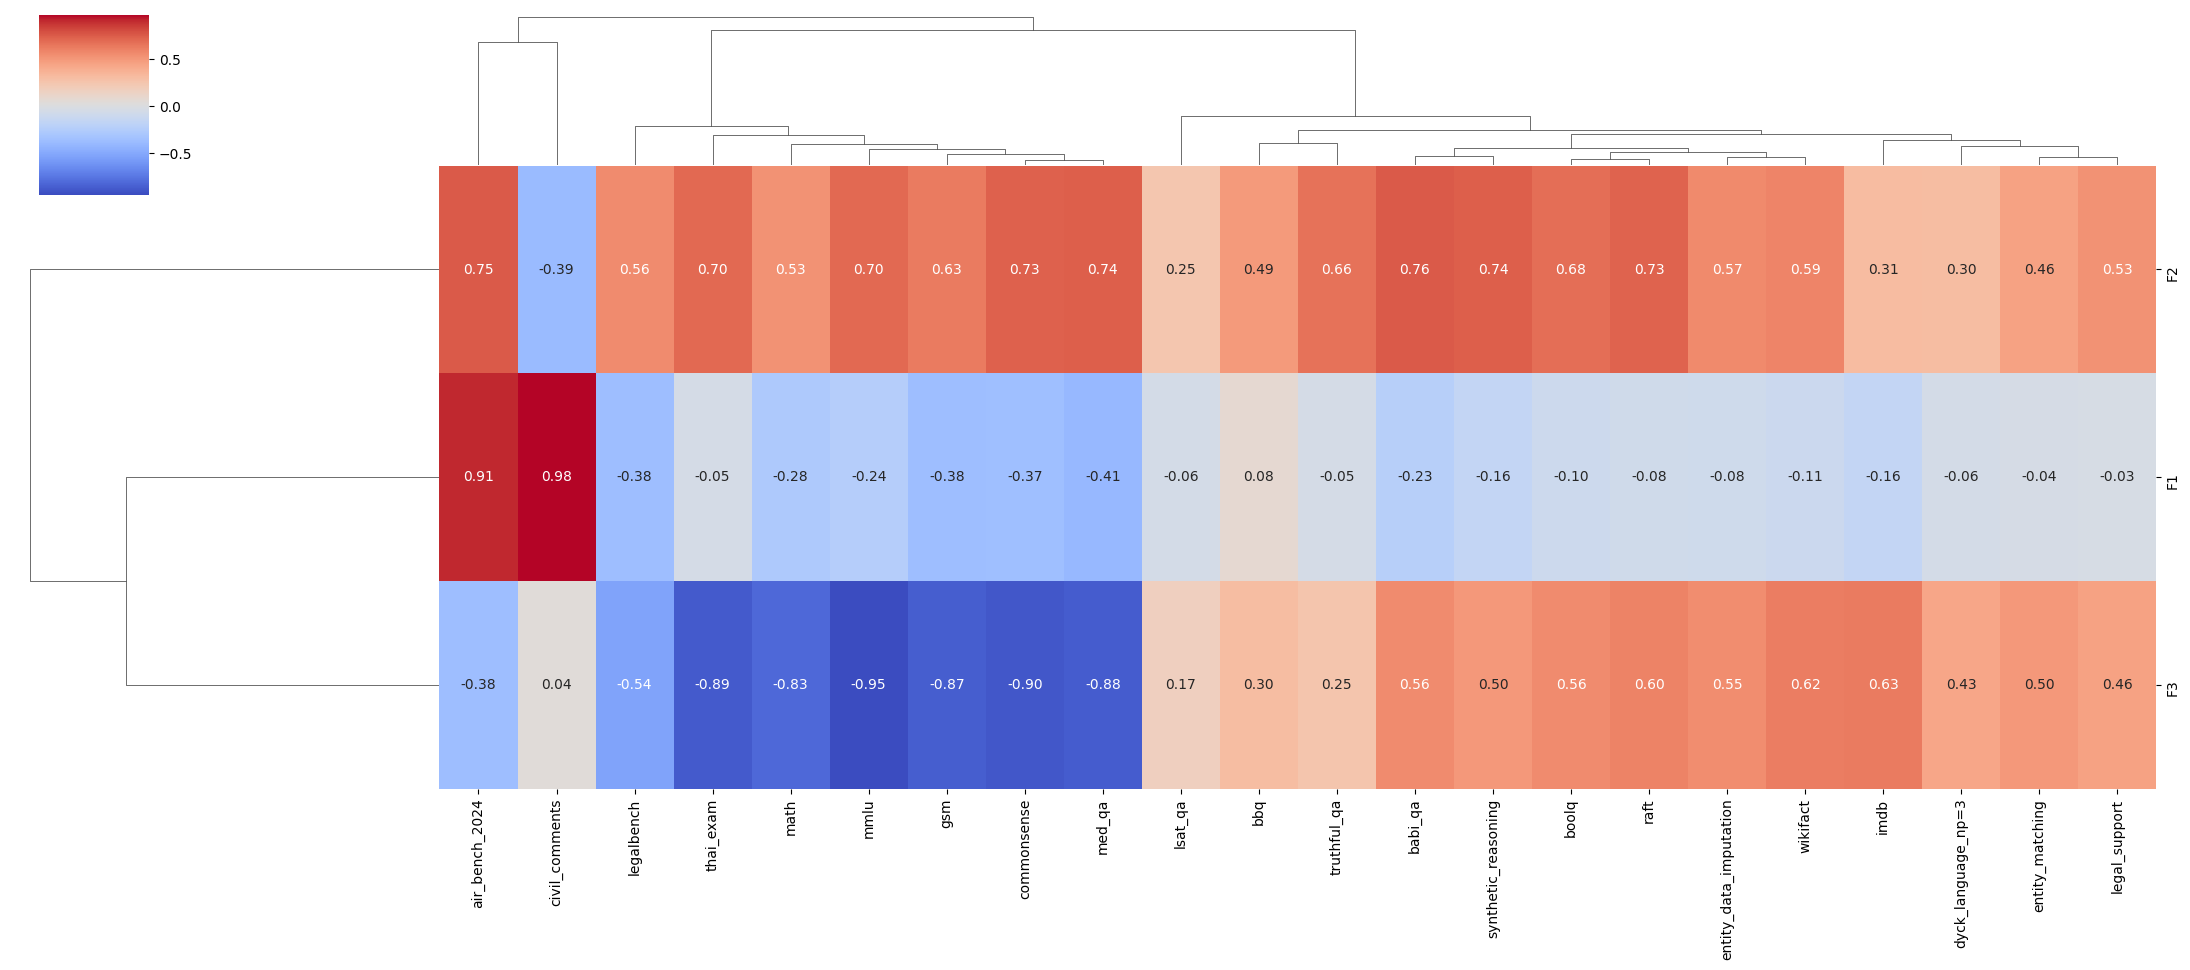

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume 'ability_df' is your (183, k) DataFrame of model abilities

# --- Step A: Aggregate resmat to get per-scenario scores ---
resmat = pd.read_pickle("../data/resmat.pkl")
scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
print(f"Created aggregated scenario scores DataFrame with shape: {scenario_scores.shape}")

# --- NEW: Step B: Identify and filter out zero-variance scenarios ---
# Calculate the standard deviation of each scenario's scores
std_devs = scenario_scores.std()

# Find the scenarios where the scores actually vary (std > 0)
scenarios_to_keep = std_devs[std_devs > 0].index
scenarios_dropped = std_devs[std_devs == 0].index

# Create a new DataFrame with only the valid scenarios
scenario_scores_filtered = scenario_scores[scenarios_to_keep]

print(f"\nDropped {len(scenarios_dropped)} scenarios with zero variance: {list(scenarios_dropped)}")
print(f"Kept {len(scenarios_to_keep)} scenarios for correlation analysis.")


# --- Step C: Combine ability scores and the FILTERED scenario scores ---
combined_df = pd.concat([ability_df, scenario_scores_filtered], axis=1)


# --- Step D: Calculate the full correlation matrix ---
full_correlations = combined_df.corr(method='spearman')

# --- Step E: Isolate the part we care about (this is the same) ---
factor_scenario_corr = full_correlations.loc[ability_df.columns, scenario_scores_filtered.columns]


# --- NEW: Step F: Plot using clustermap for automatic similarity-based sorting ---

# sns.clustermap will automatically reorder the columns (and rows)
# to place similar items next to each other based on their correlation patterns.
g = sns.clustermap(
	factor_scenario_corr,
	annot=True,          # Show the correlation values
	cmap='coolwarm',       # Use a diverging colormap
    fmt='.2f',           # Format numbers to 2 decimal places
    figsize=(22, 10),     # Adjust size for better readability
)

g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
# Save the figure
plt.savefig("../result/factor-scenario-correlations_clustered.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


--- Generating Bar Chart Profiles for Each Scenario ---


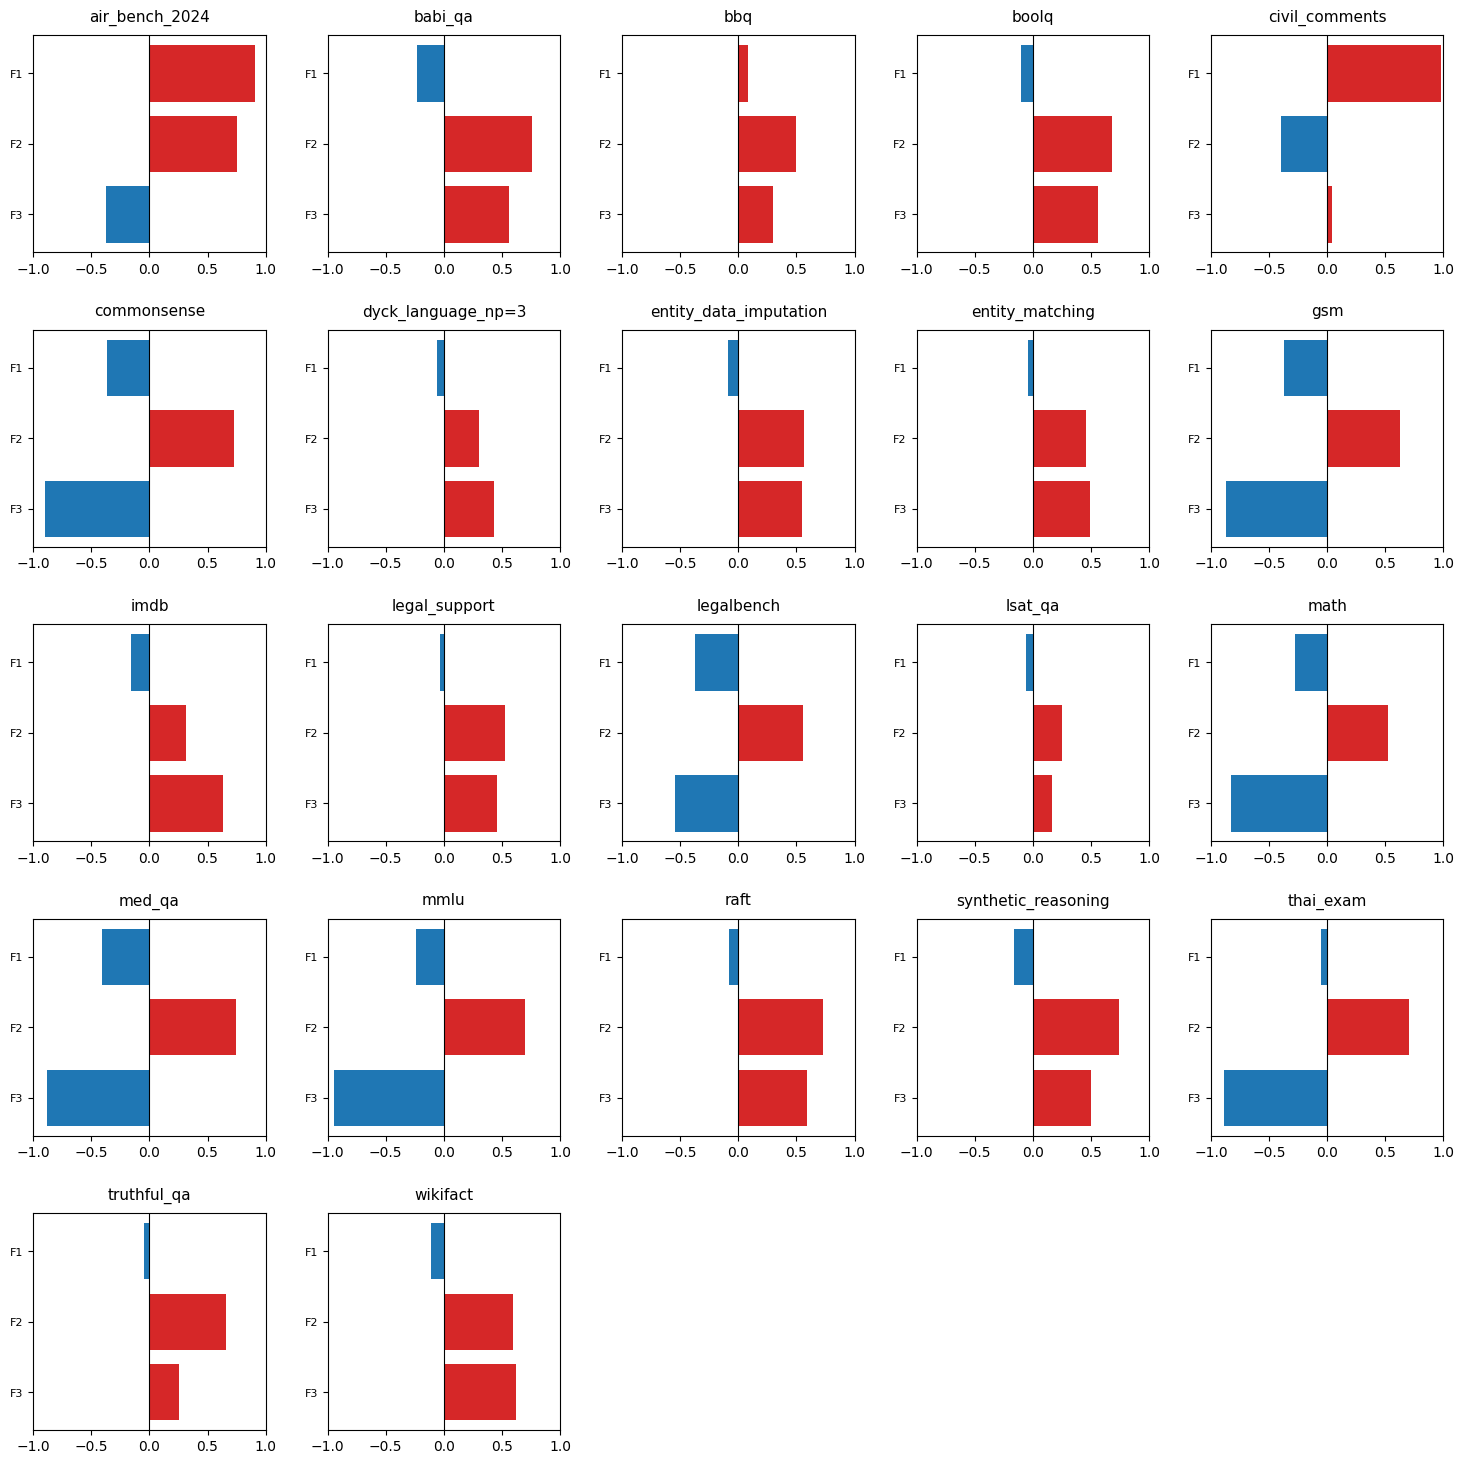

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

factor_scenario_corr = full_correlations.loc[ability_df.columns, scenario_scores_filtered.columns]

# ===================================================================
# == NEW: Code to Generate Bar Chart Profiles
# ===================================================================

def plot_correlation_bars(ax, values, labels, title):
    """Helper function to draw a horizontal bar chart of correlations."""
    y_pos = np.arange(len(labels))
    
    # Create colors: red for positive, blue for negative
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in values]
    
    # Plot the bars
    ax.barh(y_pos, values, color=colors)
    
    # Set labels and title
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()  # labels read top-to-bottom
    # ax.set_xlabel('Spearman Correlation', fontsize=8)
    ax.set_title(title, size=11, pad=10)
    
    # Set x-axis limits and add a vertical line at zero
    ax.set_xlim(-1.0, 1.0)
    ax.axvline(0, color='black', linewidth=0.8)


# --- Main Plotting Logic ---
factors = factor_scenario_corr.index.tolist()
scenarios = factor_scenario_corr.columns.tolist()
num_scenarios = len(scenarios)

# Create a grid of subplots (NOT polar this time)
num_cols = 5
num_rows = int(np.ceil(num_scenarios / num_cols))

fig, axes = plt.subplots(figsize=(15, num_rows * 3), nrows=num_rows, ncols=num_cols)

print("\n--- Generating Bar Chart Profiles for Each Scenario ---")

axes_flat = axes.flatten()

# Loop through each scenario and draw its chart
for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    values = factor_scenario_corr[scenario].tolist()
    plot_correlation_bars(ax, values, factors, scenario)

# Hide any unused subplots
for i in range(num_scenarios, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig("../result/factor-scenario-bar-profiles.png", dpi=300, bbox_inches='tight')
plt.show()

--- Standardizing the new projected factors ---
--- Saving the new factors ---
--- Generating Final Radial Heatmaps ---


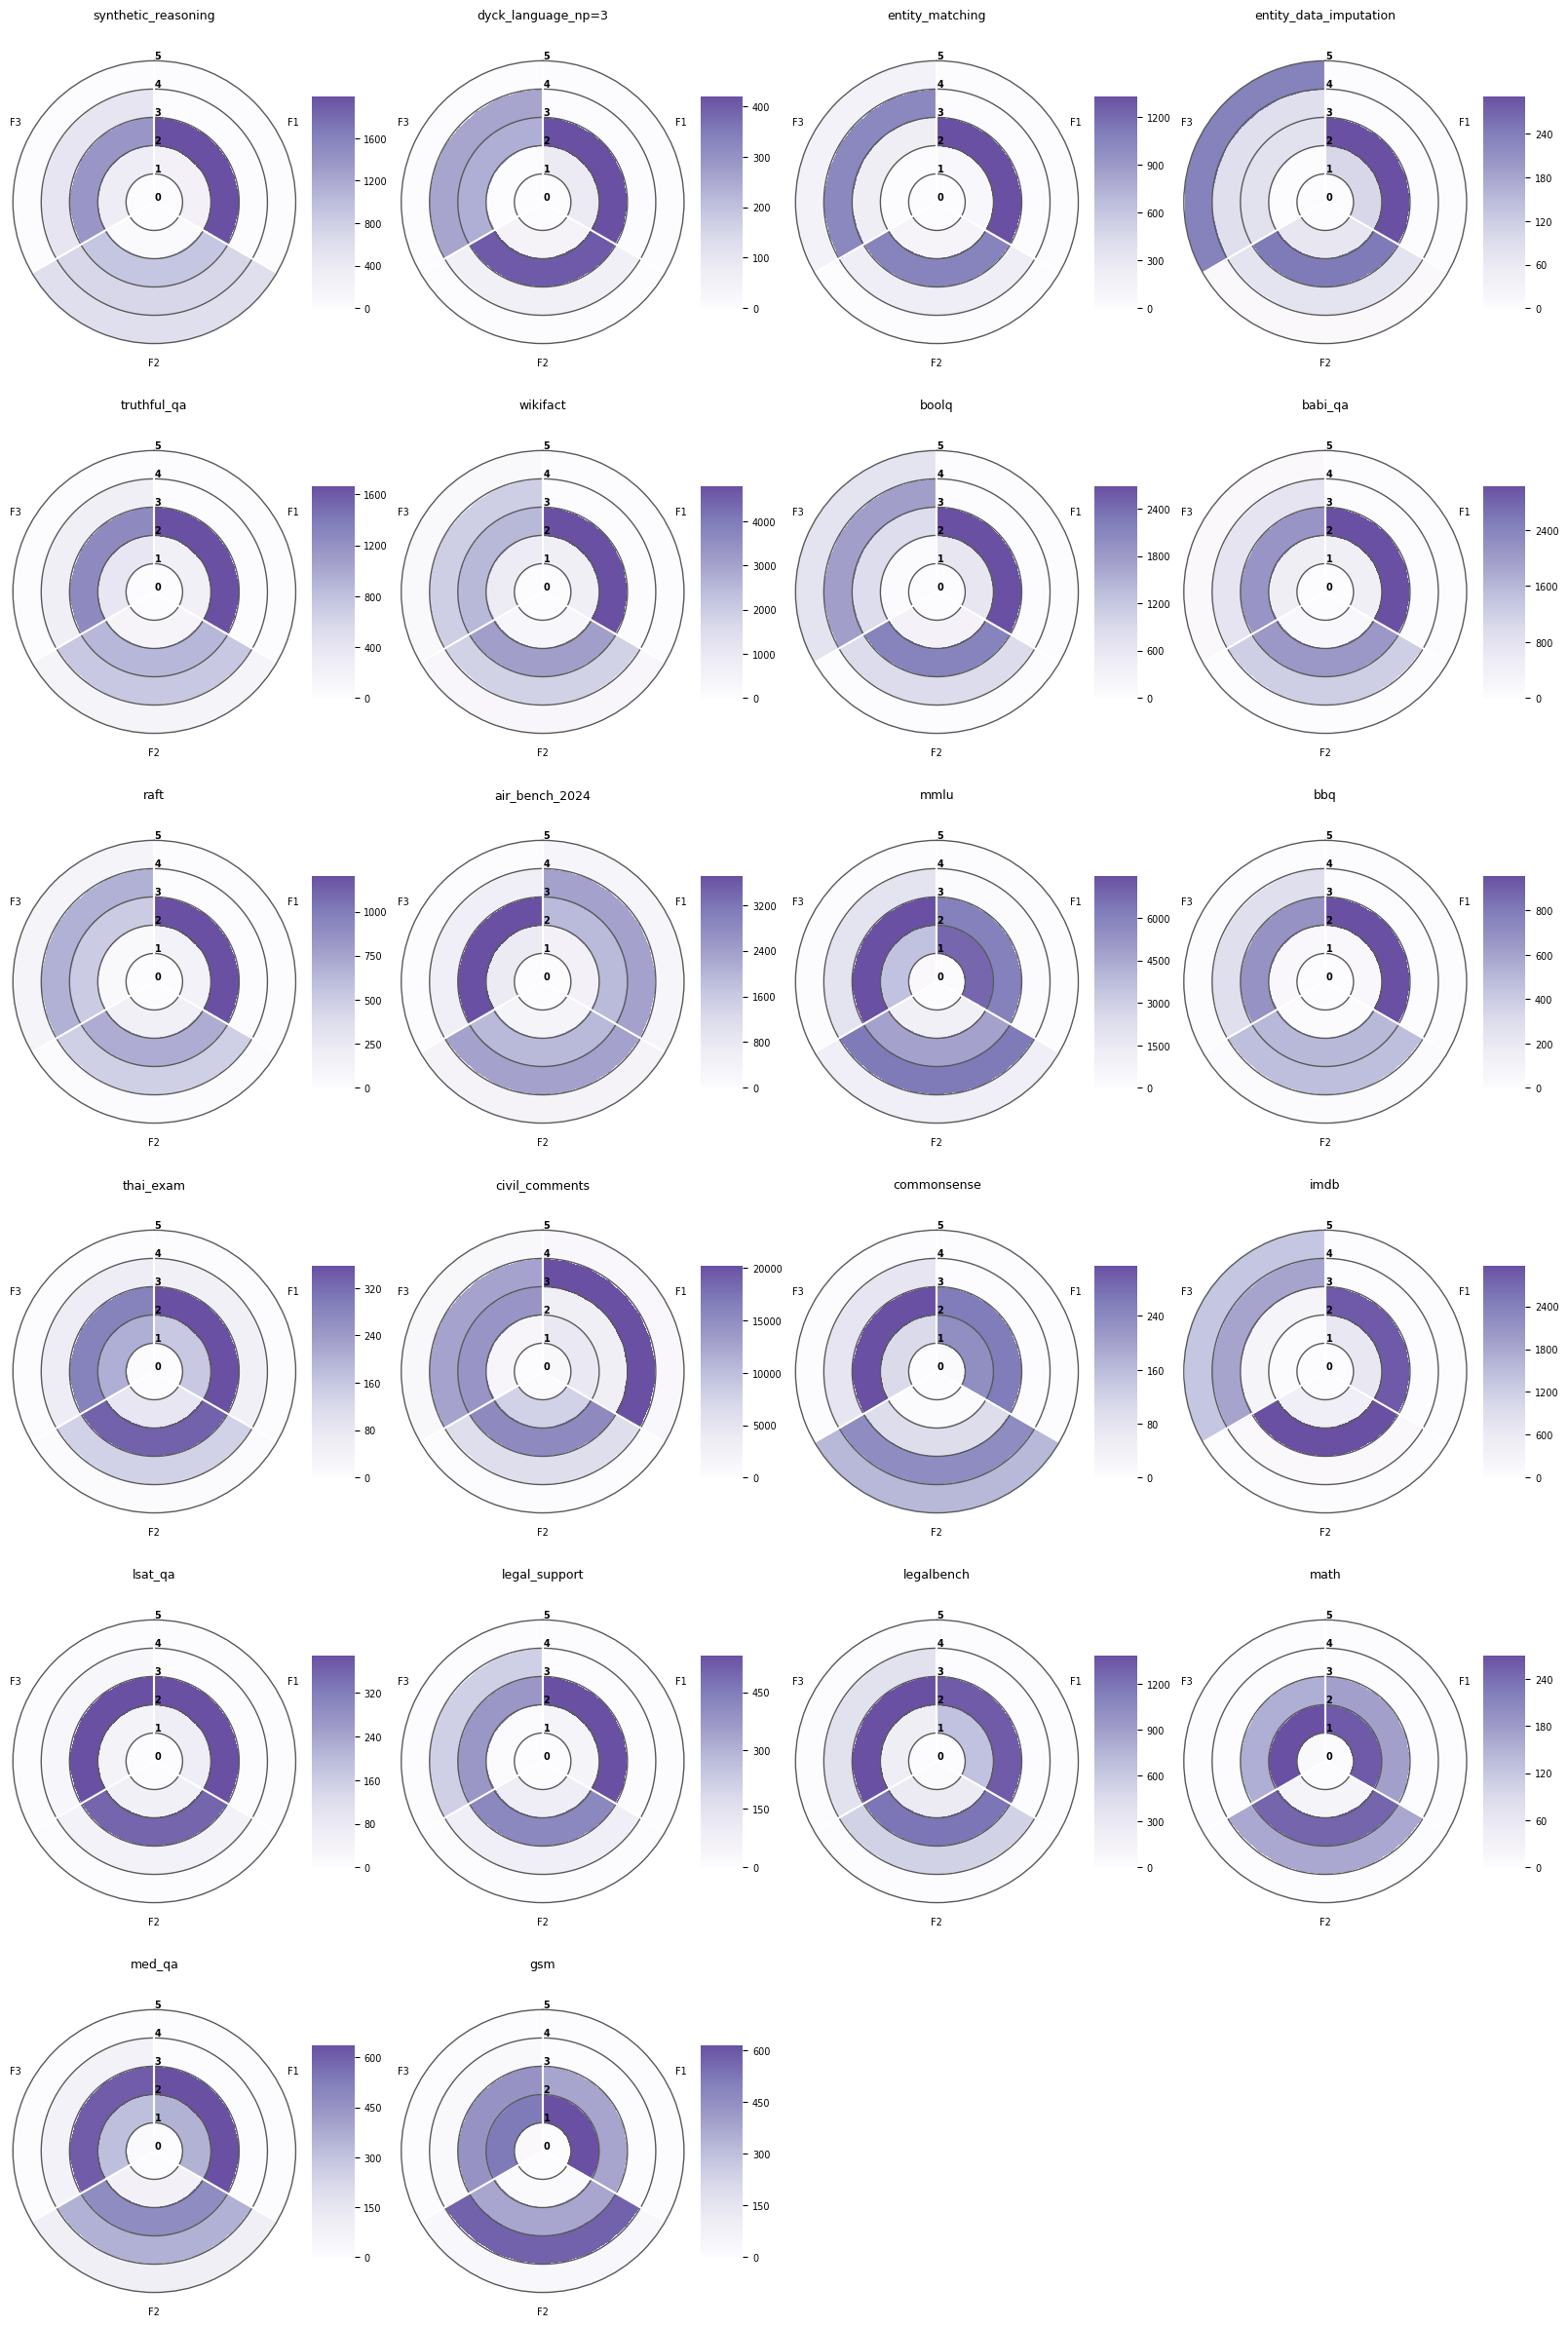

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import MinMaxScaler
import matplotlib.ticker as mticker

scenario_mapping = {
	"Factual Knowledge & Question Answering": {
		"boolq": "Requires answering yes/no questions where the answer is directly supported by a provided text passage.",
		"wikifact": "Involves fact-checking and verifying the truthfulness of statements against a knowledge source like Wikipedia.",
		"truthful_qa": "Measures a model's ability to provide true answers and avoid generating common falsehoods."
	},
	"Specialised reasoning": {
		"math": "Involves solving competition-level mathematics problems, requiring advanced numerical and symbolic reasoning.",
		"gsm": "Stands for Grade-School Math; tests multi-step quantitative reasoning on word problems.",
		"lsat_qa": "Tests analytical reasoning and logic puzzles modeled after the Law School Admission Test.",
		"legal_support": "Requires identifying a supporting legal passage for a given statement from a set of candidates.",
		"legalbench": "A broad suite of diverse benchmarks covering various legal reasoning tasks.",
		"med_qa": "Focuses on question answering in the medical domain, requiring specialized, expert-level knowledge."
	},
	"Language & Social Reasoning": {
		"civil_comments": "A dataset for toxicity detection, requiring an understanding of nuanced and potentially offensive language.",
		"imdb": "A classic sentiment analysis task for movie reviews, testing the understanding of opinionated text.",
		"bbq": "Bias Benchmark for QA; specifically designed to probe for and expose social biases in model responses.",
		"commonsense": "A general category for tasks evaluating everyday reasoning and an implicit understanding of the world.",
		"thai_exam": "Tests knowledge and language understanding based on questions from Thai academic examinations."
	},
	"Details & Logical reasoning": {
		"entity_matching": "Involves identifying if two different descriptions or records refer to the same real-world entity.",
		"entity_data_imputation": "The task of filling in missing values (imputation) for entities within a structured dataset.",
		"synthetic_reasoning": "Evaluates reasoning on procedurally generated, abstract problems to isolate logical capabilities.",
		"dyck_language_np=3": "A formal language task that tests structural understanding by checking for balanced parentheses."
	},
	"General & Multitask Evaluation": {
		"mmlu": "Massive Multitask Language Understanding; a broad benchmark covering 57 diverse academic subjects.",
		"air_bench_2024": "A comprehensive benchmark for evaluating the instruction-following capabilities of AI models across many tasks.",
		"raft": "Real-world Annotated Few-shot Tasks; a collection of diverse classification tasks with limited training examples.",
		"babi_qa": "Tests specific deductive reasoning skills using simple text-based stories and questions.",
	}
}

group_color_map = {
	"Factual Knowledge & Question Answering": "Purples",
	"Specialised reasoning": "Purples",
	"Language & Social Reasoning": "Purples",
	"Details & Logical reasoning": "Purples",
	"General & Multitask Evaluation": "Purples"
}

# 2. Create a reverse mapping from individual scenario to its group name for easy lookup.
scenario_to_group_map = {}
for group, scenarios in scenario_mapping.items():
	for scenario in scenarios.keys():
		scenario_to_group_map[scenario] = group

# --- UPDATED FUNCTION ---
def plot_scenario_heatmap(scaled_scenario_factors: np.ndarray, scenario_labels: np.ndarray, unique_scenarios: list, group_color_map: dict, scenario_to_group_map: dict):
	"""
	Generates a clean, arc-shaped radial heatmap with a styled border.
	Colors each plot based on its scenario group.
	"""
	# 1. Combine data into a DataFrame
	factor_names = [f'F{i+1}' for i in range(scaled_scenario_factors.shape[1])]
	loadings_df = pd.DataFrame(scaled_scenario_factors, columns=factor_names)
	loadings_df['scenario'] = scenario_labels

	r_bins_data = np.array([0, 1, 2, 3, 4, 5])
	r_tick_labels = [f"$\\bf{{{b}}}$" for b in r_bins_data]  # Bold tick labels using LaTeX
	r_bins_plot = r_bins_data + 1 # We plot on a positive radius

	# 3. Setup the plot grid
	num_scenarios = len(unique_scenarios)
	num_cols = 4
	num_rows = int(np.ceil(num_scenarios / num_cols))

	fig, axes = plt.subplots(
		figsize=(num_cols * 4, num_rows * 4),
		nrows=num_rows,
		ncols=num_cols,
		subplot_kw={'projection': 'polar'},
		layout="constrained"
	)
	axes_flat = axes.flatten()
	print("--- Generating Final Radial Heatmaps ---")

	# 4. Loop through each scenario
	for i, scenario in enumerate(unique_scenarios):
		ax = axes_flat[i]
		scenario_data = loadings_df[loadings_df['scenario'] == scenario][factor_names]
		if scenario_data.empty:
			ax.set_title(f"{scenario}\n(No Data)", size=9, y=1.1)
			ax.set_yticklabels([]); ax.set_xticklabels([])
			continue
		counts_matrix = np.zeros((len(r_bins_data) - 1, len(factor_names)))
		for j, factor in enumerate(factor_names):
			counts, _ = np.histogram(scenario_data[factor].dropna(), bins=r_bins_data)
			counts_matrix[:, j] = counts

		theta_edges = np.linspace(0, 2 * np.pi, len(factor_names) + 1)
		angular_upsample_factor = 10
		upsampled_counts = np.repeat(counts_matrix, angular_upsample_factor, axis=1)
		theta_edges_fine = np.linspace(0, 2 * np.pi, (len(factor_names) * angular_upsample_factor) + 1)
		r_edges = r_bins_plot
		T, R = np.meshgrid(theta_edges_fine, r_edges)
		vmax = np.max(counts_matrix)
		norm = mcolors.Normalize(vmin=0, vmax=vmax)

		# --- NEW DYNAMIC COLORMAP LOGIC ---
		# 1. Find the group and corresponding colormap name for the current scenario
		group = scenario_to_group_map.get(scenario, "DefaultGroup")
		cmap_name = group_color_map.get(group, "Greys") # Default to 'Greys' if group is not found

		# 2. Get the original colormap from matplotlib
		original_cmap = plt.get_cmap(cmap_name)

		# 3. Create a new colormap using the first 85% of the original's colors
		cmap = mcolors.LinearSegmentedColormap.from_list(
			f"truncated_{cmap_name}", original_cmap(np.linspace(0, 0.75, 256))
		)
		# --- END OF NEW LOGIC ---

		mesh = ax.pcolormesh(T, R, upsampled_counts + 1, cmap=cmap, norm=norm, shading='auto')

		ax.set_axisbelow(False)
		ax.xaxis.grid(False)
		ax.yaxis.grid(False)

		theta_circle = np.linspace(0, 2 * np.pi, 200)
		# This is the plot coordinate that corresponds to your original data's zero point
		zero_line_radius = 1.0

		for r_val in r_bins_plot[:-1]:
			# Check if the current radius is the one we want to style differently
			if np.isclose(r_val, zero_line_radius) and False: # Temporarily disable the dashed line
				# Apply special styling for the zero line
				ax.plot(theta_circle, np.full_like(theta_circle, r_val), color='black', lw=1, linestyle='--', zorder=5)
			else:
				# Regular styling for all other grid lines
				ax.plot(theta_circle, np.full_like(theta_circle, r_val), color='#5a5a5a', lw=1)

		# This part for the radial spokes is correct and can remain as is
		for theta in theta_edges:
			ax.plot([theta, theta], [r_bins_plot[0], r_bins_plot[-1]], color='white', lw=1.5)

		ax.spines['polar'].set_color('#5a5a5a')
		ax.spines['polar'].set_linewidth(1)
		ax.spines['polar'].set_zorder(3)

		ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
		
		theta_centers = theta_edges[:-1] + (theta_edges[1] - theta_edges[0]) / 2
		ax.set_xticks(theta_centers)
		ax.set_xticklabels(factor_names, size=7, rotation_mode='anchor', ha='center')
		ax.set_rlim(r_bins_plot[0], r_bins_plot[-1])
		ax.set_yticks(r_bins_plot)
		ax.set_yticklabels(r_tick_labels, fontsize=7)
		ax.set_rlabel_position(0)
		ax.set_title(scenario, size=9, y=1.12)
		cbar = fig.colorbar(mesh, ax=ax, shrink=0.8, aspect=5)
		cbar.ax.tick_params(labelsize=7)
		# cbar.set_label('Frequency', rotation=270, labelpad=15, fontsize=8)
		cbar.outline.set_visible(False)
		cbar.ax.yaxis.set_major_locator(mticker.MaxNLocator(5))

	for i in range(num_scenarios, len(axes_flat)):
		axes_flat[i].set_visible(False)
	plt.savefig(f"../result/factor-scenario-radial-profiles.png", dpi=300, bbox_inches='tight')
	plt.show()
	
# --- REVISED WORKFLOW ---

# 1. Load your full resmat and scenario labels (as you already have)
resmat = pd.read_pickle("../data/resmat.pkl")
balanced_resmat_full = resmat.columns.to_frame()
unique_scenarios = balanced_resmat_full['scenario'].unique().tolist()
scenario_labels = balanced_resmat_full['scenario'].values

all_item_factors = a_for_z_numpy

# 4. Standardize the new factors to a [0, 5] range
print("--- Standardizing the new projected factors ---")
scaler = MinMaxScaler(feature_range=(0, 5))
scaled_factors = scaler.fit_transform(all_item_factors)

print("--- Saving the new factors ---")
np.save("../result/scaled_factors.npy", scaled_factors)

sorted_scenarios = sorted(unique_scenarios, key=lambda s: scenario_to_group_map.get(s, "zzzz_default"))

# 5. Call the plotting function with the new, correctly calculated factors
plot_scenario_heatmap(
	scaled_factors,
	scenario_labels,
	sorted_scenarios,
	group_color_map,          # Pass the color map
	scenario_to_group_map     # Pass the lookup map
)

In [30]:
from sklearn.manifold import TSNE

# ===================================================================
# == Step 2: Extract the Scenario Representations
# ===================================================================
# The matrix `model_final.components_` has a shape of (k, n_scenarios).
# We need to transpose it to get (n_scenarios, k) for t-SNE.
scenario_factors = a_for_z_numpy
print(f"Extracted scenario factors with shape: {scenario_factors.shape}")

# ===================================================================
# == Step 3: Run t-SNE to Reduce to 2 Dimensions
# ===================================================================
print("\nRunning t-SNE to reduce dimensions for visualization...")
# Note: t-SNE can be slow on large datasets. This might take a few minutes.
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
scenario_2d = tsne.fit_transform(scenario_factors)
print(f"t-SNE complete. New data shape: {scenario_2d.shape}")

Extracted scenario factors with shape: (78712, 7)

Running t-SNE to reduce dimensions for visualization...
t-SNE complete. New data shape: (78712, 2)


In [32]:
np.save("../result/scenario_2d.npy", scenario_2d)
np.save("../result/scenario_factors.npy", scenario_factors)

/tmp/ipykernel_8641/1970126760.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(unique_scenarios))



Generating plot...


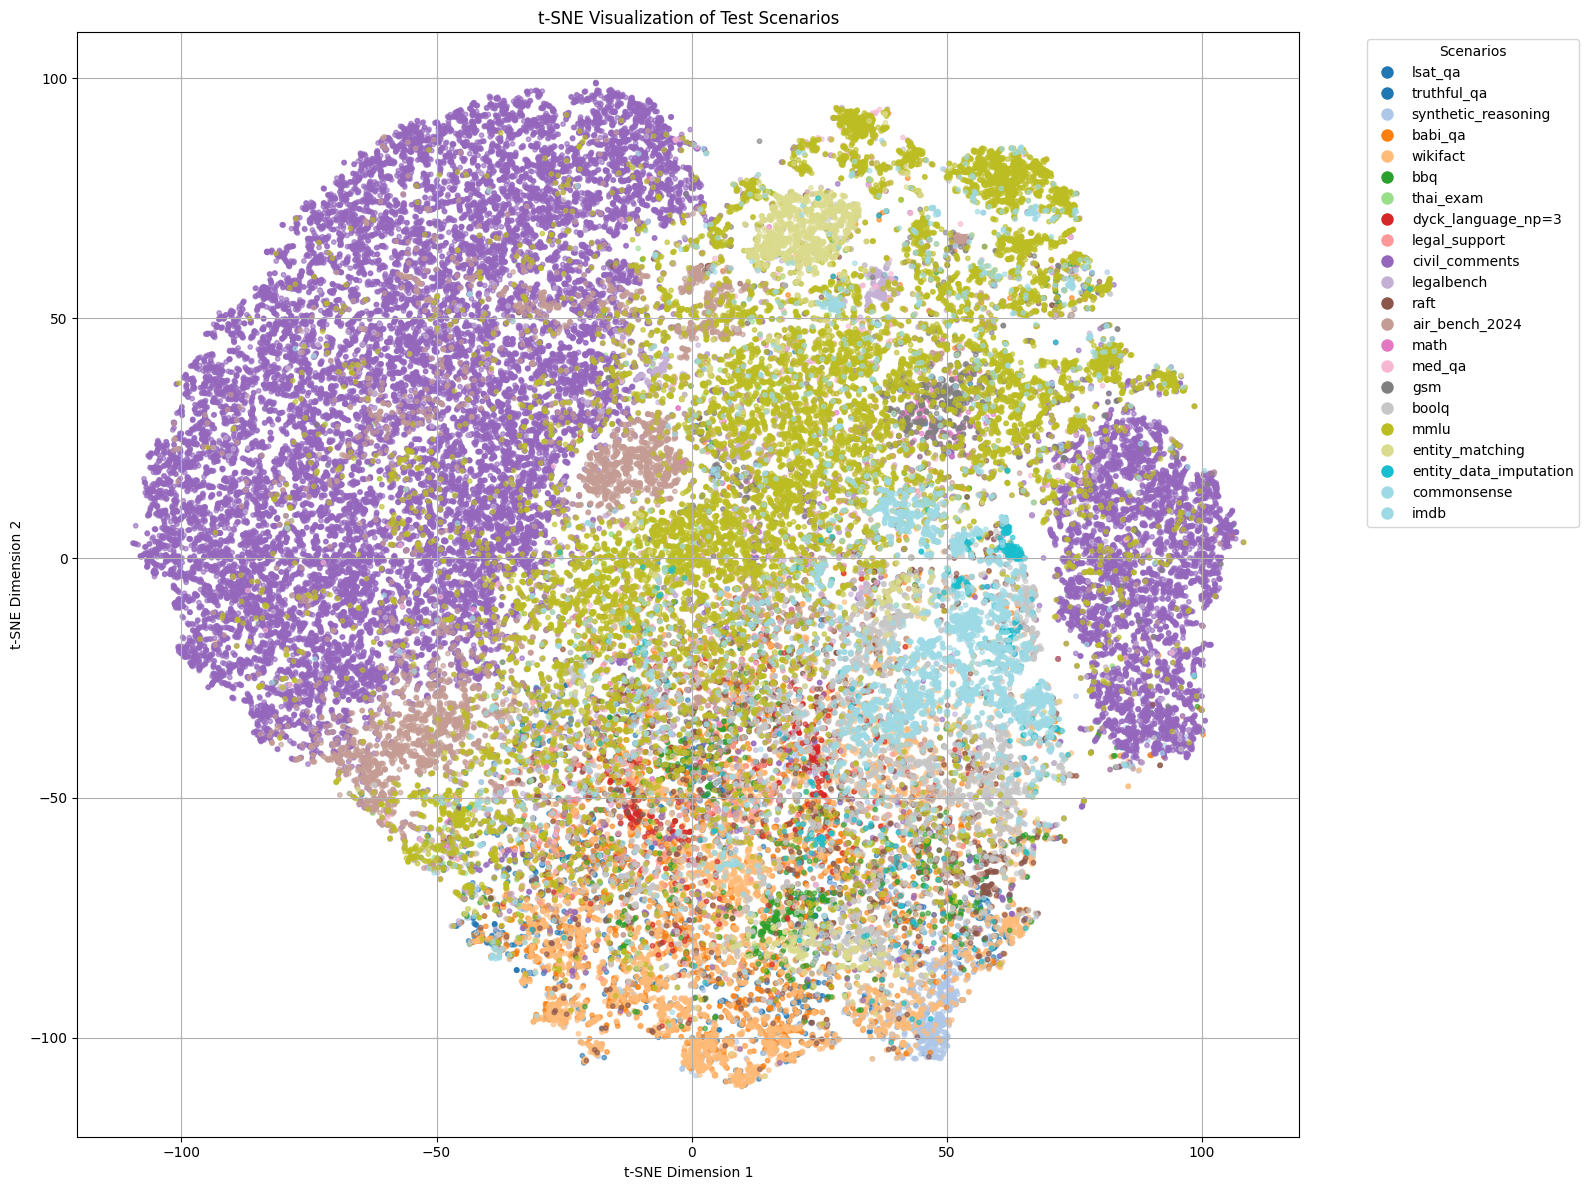

In [33]:
import matplotlib.cm as cm

# ===================================================================
# == Step 4: Create an Interpretable Visualization
# ===================================================================
# To color the plot, we need to know which scenario each of the 78,712 columns belongs to.
# Let's load the scenario names and the mapping you created in your notebook.

# Load the list of unique scenario names (there should be 22)
balanced_resmat = pd.read_pickle("../data/resmat.pkl").columns.to_frame()
unique_scenarios = balanced_resmat['scenario'].unique().tolist()

# Get the scenario label for each of the 78,712 columns
scenario_labels = balanced_resmat['scenario'].values

# Create a color map for the unique scenarios
colors = cm.get_cmap('tab20', len(unique_scenarios))
color_map = {scenario: colors(i) for i, scenario in enumerate(unique_scenarios)}
point_colors = [color_map[label] for label in scenario_labels]

print("\nGenerating plot...")
plt.figure(figsize=(16, 12))
scatter = plt.scatter(scenario_2d[:, 0], scenario_2d[:, 1], c=point_colors, alpha=0.6, s=10)

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=scen,
                      markerfacecolor=color_map[scen], markersize=10) for scen in unique_scenarios]
plt.legend(handles=handles, title='Scenarios', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('t-SNE Visualization of Test Scenarios')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig(f"../result/factor-scenario-radial-profiles.png", dpi=300, bbox_inches='tight')
plt.grid(True)
plt.tight_layout()
plt.show()